In [1]:
# kernel : R_edgeR
library(dplyr)
library(Seurat)
library(edgeR)
library(ggplot2)
library(tidyr)
library(ggpubr)  # For p-value annotation
library(arrow)
library(pheatmap)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘Seurat’ was built under R version 4.4.1”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.1”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.4.1”
‘SeuratObject’ was built with package ‘Matrix’ 1.6.5 but the current
version is 1.7.1; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: limma

Warning message:
“package ‘ggpubr’ was built under R version 4.4.1”
Warning message:
“package ‘arrow’ was built under R version 4.4.2”

Attaching package: ‘arrow’


The following object is masked fro

In [2]:
LoadXenium2<-function (data.dir, fov = "fov", assay = "Xenium") 
{
    data <- ReadXenium(data.dir = data.dir, type = c("centroids", 
        "segmentations"), )
    segmentations.data <- list(centroids = CreateCentroids(data$centroids), 
        segmentation = CreateSegmentation(data$segmentations))
    coords <- CreateFOV(coords = segmentations.data, type = c("segmentation", 
        "centroids"), molecules = data$microns, assay = assay)
    xenium.obj <- CreateSeuratObject(counts = data$matrix[["Gene Expression"]], 
        assay = assay)
    xenium.obj[["ControlCodeword"]] <- CreateAssayObject(counts = data$matrix[["Negative Control Codeword"]])
    xenium.obj[["ControlProbe"]] <- CreateAssayObject(counts = data$matrix[["Negative Control Probe"]])
    xenium.obj[[fov]] <- coords
    return(xenium.obj)
}


# Function to plot gene expression across predicted cell types
plot_gene_expression <- function(seurat_obj, genes) {
  for (gene in genes) {
    # Extract expression matrix
    expr_matrix <- as.data.frame(GetAssayData(seurat_obj, slot = "counts"))
    
    # Check if the gene is present in the dataset
    if (!(gene %in% rownames(expr_matrix))) {
      message(paste("Warning: Gene", gene, "not found in the dataset. Skipping..."))
      next
    }
    
    # Identify cells expressing the gene (nonzero counts)
    expr_cells <- colnames(expr_matrix)[expr_matrix[gene, ] > 0]
    
    # Create a data frame for plotting
    expr_df <- data.frame(
      cell = expr_cells,
      predicted.id = seurat_obj$predicted.id[expr_cells]
    )
    
    # Count the number of cells per `predicted.id`
    expr_counts <- expr_df %>%
      group_by(predicted.id) %>%
      summarise(num_cells = n())
    
    # Generate the plot
    p <- ggplot(expr_counts, aes(x = predicted.id, y = num_cells, fill = predicted.id)) +
      geom_bar(stat = "identity") +
      theme_minimal() +
      labs(x = "Cell Type (predicted.id)", y = "Number of Expressing Cells",
           title = paste("Cells Expressing", gene)) +
      theme(axis.text.x = element_text(angle = 45, hjust = 1))
    
    # Print the plot
    print(p)
  }
}


# Function to generate box plots for multiple genes, filtering out zero-expression cells
plot_boxplot_gene_expression <- function(seurat_obj, genes) {
  options(repr.plot.width = 15, repr.plot.height = 5) # Adjust plot size
  
  for (gene in genes) {
    if (!(gene %in% rownames(seurat_obj))) {
      message(paste("Warning: Gene", gene, "not found in the dataset. Skipping..."))
      next
    }
    
    # Extract expression data
    expr_data <- FetchData(seurat_obj, vars = c(gene, "predicted.id"))
    
    # Rename columns for clarity
    colnames(expr_data) <- c("Expression", "CellType")
    
    # Filter out cells with zero expression
    expr_data <- expr_data %>% filter(Expression > 0)
    
    if (nrow(expr_data) == 0) {
      message(paste("No nonzero expression found for", gene, "- skipping plot."))
      next
    }
    
    # Generate box plot
    p <- ggplot(expr_data, aes(x = CellType, y = Expression, fill = CellType)) +
      geom_boxplot(outlier.shape = NA) + # Box plot without outliers
      geom_jitter(width = 0.2, alpha = 0.4, size = 1) + # Add jitter for visibility
      theme_minimal() +
      labs(title = paste("Expression of", gene), x = "Cell Type (predicted.id)", y = "Expression Level") +
      theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none") # Rotate x-axis labels
    
    print(p)  # Print each plot
  }
}



# Function to generate violin plots for multiple genes, filtering out zero-expression cells
plot_violin_gene_expression <- function(seurat_obj, genes) {
  options(repr.plot.width = 15, repr.plot.height = 5) # Adjust plot size

  for (gene in genes) {
    if (!(gene %in% rownames(seurat_obj))) {
      message(paste("Warning: Gene", gene, "not found in the dataset. Skipping..."))
      next
    }
    
    # Extract expression data
    expr_data <- FetchData(seurat_obj, vars = c(gene, "predicted.id"))
    
    # Rename columns for clarity
    colnames(expr_data) <- c("Expression", "CellType")
    
    # Filter out cells with zero expression
    expr_data <- expr_data %>% filter(Expression > 0)
    
    if (nrow(expr_data) == 0) {
      message(paste("No nonzero expression found for", gene, "- skipping plot."))
      next
    }

    # Generate violin plot
    p <- ggplot(expr_data, aes(x = CellType, y = Expression, fill = CellType)) +
      geom_violin(scale = "width", trim = TRUE) + # Violin plot
      geom_jitter(width = 0.2, alpha = 0.4, size = 1) + # Jitter for visibility
      theme_minimal() +
      labs(title = paste("Expression of", gene), x = "Cell Type (predicted.id)", y = "Expression Level") +
      theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none") # Rotate x-axis labels
    
    print(p)  # Print each plot
  }
}


plot_bar_total_expression <- function(seurat_obj, genes) {
  options(repr.plot.width = 15, repr.plot.height = 5) # Adjust plot size
  
  for (gene in genes) {
    if (!(gene %in% rownames(seurat_obj))) {
      message(paste("Warning: Gene", gene, "not found in the dataset. Skipping..."))
      next
    }
    
    # Extract raw counts instead of scaled values
    expr_data <- FetchData(seurat_obj, vars = c(gene, "predicted.id"))
    
    # Rename columns for clarity
    colnames(expr_data) <- c("Expression", "CellType")
    
    # Filter out zero-expressing cells
    expr_data <- expr_data %>% filter(Expression > 0)
    
    if (nrow(expr_data) == 0) {
      message(paste("No nonzero expression found for", gene, "- skipping plot."))
      next
    }

    # Calculate total expression per cell type
    expr_summary <- expr_data %>%
      group_by(CellType) %>%
      summarise(total_exp = sum(Expression)) %>%
      arrange(desc(total_exp)) # Sort by highest total expression

    # Generate bar plot
    p <- ggplot(expr_summary, aes(x = reorder(CellType, -total_exp), y = total_exp, fill = CellType)) +
      geom_bar(stat = "identity", alpha = 0.8) +  # Bar height = total expression
      theme_minimal() +
      labs(title = paste("Total Expression of", gene), x = "Cell Type", y = "Total Expression Counts") +
      theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none") # Rotate labels
    
    print(p)  # Print each plot
  }
}




# Downsample function
downsample_seurat <- function(seurat_obj, target_n_cells) {
    # Get the cell type proportions
    celltype_proportions <- table(seurat_obj$Cell_Type_Annotation) / length(seurat_obj$Cell_Type_Annotation)
    
    # Calculate the number of cells to sample from each cell type based on the proportions
    n_cells_by_type <- round(celltype_proportions * target_n_cells)
    
    # Create an empty list to store the downsampled cells for each cell type
    downsampled_cells <- list()
    
    # Loop over each cell type and sample the appropriate number of cells
    for (celltype in names(n_cells_by_type)) {
        # Get cells for the current cell type
        cells_of_type <- WhichCells(seurat_obj, expression = Cell_Type_Annotation == celltype)
        
        # Downsample if there are more cells of this type than needed
        if (length(cells_of_type) > n_cells_by_type[celltype]) {
            set.seed(111)  # For reproducibility
            sampled_cells <- sample(cells_of_type, n_cells_by_type[celltype])
        } else {
            sampled_cells <- cells_of_type  # If there are fewer cells than needed, keep all
        }
        
        # Add sampled cells to the list
        downsampled_cells[[celltype]] <- sampled_cells
    }
    
    # Combine all sampled cells
    downsampled_cells_all <- unlist(downsampled_cells)
    
    # Subset Seurat object to keep only the downsampled cells
    downsampled_seurat_obj <- subset(seurat_obj, cells = downsampled_cells_all)
    
    return(downsampled_seurat_obj)
}


# Function to plot proportion of cells expressing selected genes in different cell types
plot_gene_expression_proportion <- function(seurat_obj, genes, assay = "counts", group_by = "predicted.id") {
  # Extract expression matrix for the specified assay
  expr_matrix <- as.data.frame(GetAssayData(seurat_obj, slot = assay))
  
  # Filter for selected genes
  expr_matrix <- expr_matrix[rownames(expr_matrix) %in% genes, ]
  
  # Convert to long format, binary expression (1 = expressed, 0 = not expressed)
  expr_long <- as.data.frame(t(expr_matrix)) %>%
    mutate(cell = rownames(.)) %>%
    pivot_longer(cols = all_of(genes), names_to = "gene", values_to = "expression") %>%
    mutate(expression_binary = ifelse(expression > 0, 1, 0))  # Convert to 1 (expressed) or 0 (not)
  
  # Add predicted.id information from metadata
  expr_long$predicted.id <- seurat_obj@meta.data[[group_by]][match(expr_long$cell, rownames(seurat_obj@meta.data))]
  
  # Calculate proportion of expressing cells per cell type
  expr_counts <- expr_long %>%
    group_by(gene, predicted.id) %>%
    summarise(
      num_expressing = sum(expression_binary),
      total_cells = n(),
      prop_expressing = num_expressing / total_cells,
      .groups = "drop"
    )
  
  # Plot as a grouped bar plot (proportion)
  ggplot(expr_counts, aes(x = predicted.id, y = prop_expressing, fill = gene)) +
    geom_bar(stat = "identity", position = "dodge") +
    theme_minimal() +
    labs(x = "Cell Type (predicted.id)", y = "Proportion of Expressing Cells", 
         title = "Proportion of Cells Expressing Selected Genes") +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    scale_fill_brewer(palette = "Set2")  # Adjust colors if needed
}



library(ggplot2)
library(dplyr)
library(tidyr)
library(Matrix)

# Function to create violin and density plots based on gene classification
plot_gene_groups_density <- function(breast) {
  # Get counts data
  counts <- GetAssayData(breast, layer = "counts")
  
  # Get gene names
  gene_names <- rownames(counts)
  
  # Classify genes
  gene_group <- case_when(
    str_starts(gene_names, "gDNA") ~ "gDNA",
    str_starts(gene_names, "cuTAR") ~ "cuTAR",
    TRUE ~ "other"
  )
  
  # Split matrix into three groups
  group_df <- data.frame(
    gene = gene_names,
    group = gene_group
  )
  
  # Get gene indices for each group
  gDNA_genes <- group_df %>% filter(group == "gDNA") %>% pull(gene)
  cuTAR_genes <- group_df %>% filter(group == "cuTAR") %>% pull(gene)
  other_genes <- group_df %>% filter(group == "other") %>% pull(gene)
  
  # Sum counts per cell for each group
  cell_counts <- data.frame(
    cell = colnames(counts),
    gDNA = Matrix::colSums(counts[gDNA_genes, , drop = FALSE]),
    cuTAR = Matrix::colSums(counts[cuTAR_genes, , drop = FALSE]),
    other = Matrix::colSums(counts[other_genes, , drop = FALSE])
  )
  
  # Reshape to long format for plotting
  cell_counts_long <- pivot_longer(cell_counts, cols = c("gDNA", "cuTAR", "other"),
                                   names_to = "group", values_to = "count")
  
  # Violin plot
  v <- ggplot(cell_counts_long, aes(x = group, y = count, fill = group)) +
    geom_violin(scale = "width", trim = TRUE) +
    scale_y_log10() +
    labs(
      title = "Total RNA Counts per Cell by Gene Group",
      x = "Gene Group",
      y = "nCount_RNA (log10)"
    ) +
    theme_minimal()
  
  # Density plot
  d <- ggplot(cell_counts_long, aes(x = log10(count), color = group, fill = group)) +
    geom_density(alpha = 0.3, adjust = 1.5) +
    scale_x_log10() +
    labs(title = "Density of Counts per Cell by Gene Group",
         x = "Counts per Cell (log10)", y = "Density") +
    theme_minimal() +
    theme(text = element_text(size = 14))
  
  # Set plot dimensions
  options(repr.plot.width = 15, repr.plot.height = 6)
  
  # Return the combined plots
  return(list(violin_plot = v, density_plot = d))
}


#  decideTestsDGE.R

decideTests.DGEExact <- decideTests.DGELRT <- function(object,adjust.method="BH",p.value=0.05,lfc=0,...)
{
	decideTestsDGE(object=object,adjust.method=adjust.method,p.value=p.value,lfc=lfc)
}

decideTestsDGE <- function(object,adjust.method="BH",p.value=0.05,lfc=0)
#	Accept or reject hypothesis tests across genes and contrasts
#	edgeR team. Original author was Davis McCarthy.
#	Created 15 August 2010. Last modified 15 July 2018.
{
#	Check object class
	if( !(is(object,"DGEExact") || is(object,"DGELRT")) ) stop("Need DGEExact or DGELRT object")

#	Apply multiple testing
	p <- object$table$PValue
	p <- p.adjust(p, method=adjust.method)
	isDE <- as.integer(p < p.value)

#	Extract logFC
	logFC <- object$table$logFC

#	Check for F-test with multiple logFC columns
	FTest <- is.null(logFC)

#	With multiple contrasts, apply lfc threshold to maximum logFC
	if(FTest) {
		if(lfc>0) {
			coef.col <- grep("^logFC",colnames(object$table))
			logFC <- object$table[,coef.col]
			SmallFC <- rowSums(abs(logFC) >= lfc) == 0
			isDE[SmallFC] <- 0L
		}

#	With single contrast, apply directionality and lfc threshold
	} else {
		isDE[isDE & logFC<0] <- -1L
		SmallFC <- (abs(logFC) < lfc)
		isDE[SmallFC] <- 0L
	}

#	Assemble TestResults object
	isDE <- matrix(isDE, ncol=1)
	row.names(isDE) <- row.names(object)
	colnames(isDE) <- paste(rev(object$comparison),collapse="-")

#	Record possible values
	if(FTest) {
		attr(isDE,"levels") <- c(0L,1L)
		attr(isDE,"labels") <- c("NotSig","Sig")
	} else {
		attr(isDE,"levels") <- c(-1L,0L,1L)
		attr(isDE,"labels") <- c("Down","NotSig","Up")
	}		

	new("TestResults", isDE)
}


setwd("/scratch/project/stseq/Prakrithi/Hon_Liver/")


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




# Liver

In [25]:
merged_obj<-readRDS("ROI_selected_full_slide_for_DE.rds")

Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


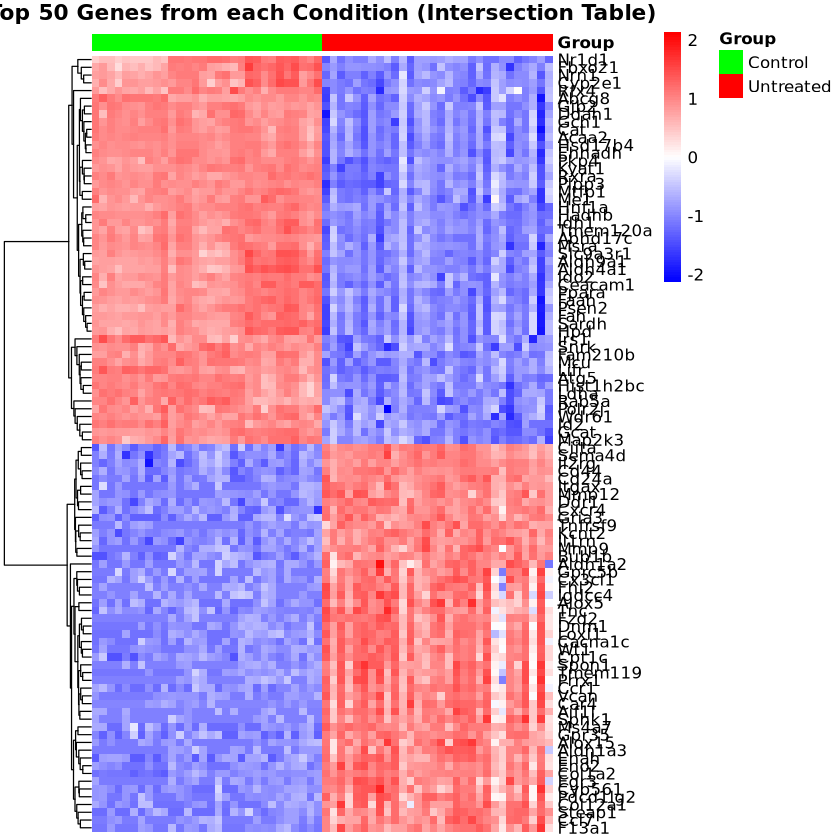

In [18]:
# ==============================
# 1️⃣ Libraries
# ==============================
library(Seurat)
library(edgeR)
library(stringr)
library(pheatmap)
library(RColorBrewer)

# ==============================
# 2️⃣ Subset & Prep
# ==============================
so_obj2 <- subset(merged_obj, subset = condition %in% c("Control", "Untreated"))
so_obj2$donor <- str_extract(so_obj2$ROI_sample, "(?<=_).*")
so_obj2$sample_id <- paste(so_obj2$donor, so_obj2$condition, sep = "_")

# ==============================
# 3️⃣ Pseudo-bulk & Metadata
# ==============================
y <- Seurat2PB(so_obj2, sample = "sample_id", cluster = "ROI_sample")
y <- normLibSizes(y)

sample_df <- data.frame(sample_id = y$samples$sample)
sample_df$donor <- factor(sub("_.*", "", sample_df$sample_id))
sample_df$condition <- factor(sub(".*_", "", sample_df$sample_id), levels = c("Control", "Untreated"))

# ==============================
# 4️⃣ Design & Dispersion (Standard edgeR flow)
# ==============================
design <- model.matrix(~ donor + condition, data = sample_df)
y <- estimateDisp(y, design, robust = TRUE)
fit <- glmQLFit(y, design, robust = TRUE)
# Running the test just to keep the workflow consistent
qlf <- glmQLFTest(fit, coef = "conditionUntreated")

# ==============================
# 5️⃣ Selection from External File
# ==============================
# Load your specific intersection table
de_from_file <- read.table("Liver_up_down_intersection_table.txt", header = TRUE, row.names = 1, sep = "\t")

# Filter out ribosomal/LINC
#filter_pattern <- "^RPS|^RPL|^LINC"
filter_pattern <- "LIN"

# Separate by condition from the file
up_file <- de_from_file[de_from_file$significance == "Up", ]
down_file <- de_from_file[de_from_file$significance == "Down", ]

# Remove ribosomal/LINC and select top 50 by FDR
top_50_up_genes <- rownames(up_file)[!grepl(filter_pattern, rownames(up_file), ignore.case = TRUE)]
top_50_up <- head(top_50_up_genes[order(up_file[top_50_up_genes, "FDR"])], 50)

top_50_down_genes <- rownames(down_file)[!grepl(filter_pattern, rownames(down_file), ignore.case = TRUE)]
top_50_down <- head(top_50_down_genes[order(down_file[top_50_down_genes, "FDR"])], 50)

# Combine for 100 genes total
top_genes <- c(top_50_up, top_50_down)

# ==============================
# 6️⃣ Heatmap
# ==============================
lcpm <- cpm(y, log = TRUE)

# Ensure genes exist in the matrix
plot_genes <- intersect(top_genes, rownames(lcpm))
heatmap_data <- lcpm[plot_genes, , drop = FALSE]

# Order samples: Control first, then Untreated
ord <- order(sample_df$condition)
heatmap_data <- heatmap_data[, ord]

annotation_col <- data.frame(Group = sample_df$condition)
rownames(annotation_col) <- colnames(lcpm)
annotation_col <- annotation_col[ord, , drop = FALSE]

# Set up Blue-White-Red Palette
my_palette <- colorRampPalette(c("blue", "white", "red"))(100)

pheatmap(
  heatmap_data,
  scale = "row",
  cluster_cols = FALSE,
  cluster_rows = TRUE,
  show_colnames = FALSE,
  border_color = NA,              # Removes grid lines
  color = my_palette,             # Blue-White-Red palette
  annotation_col = annotation_col,
  annotation_colors = list(Group = c(Control = "green", Untreated = "red")),
  main = "Top 50 Genes from each Condition (Intersection Table)"
)

pdf 
  2

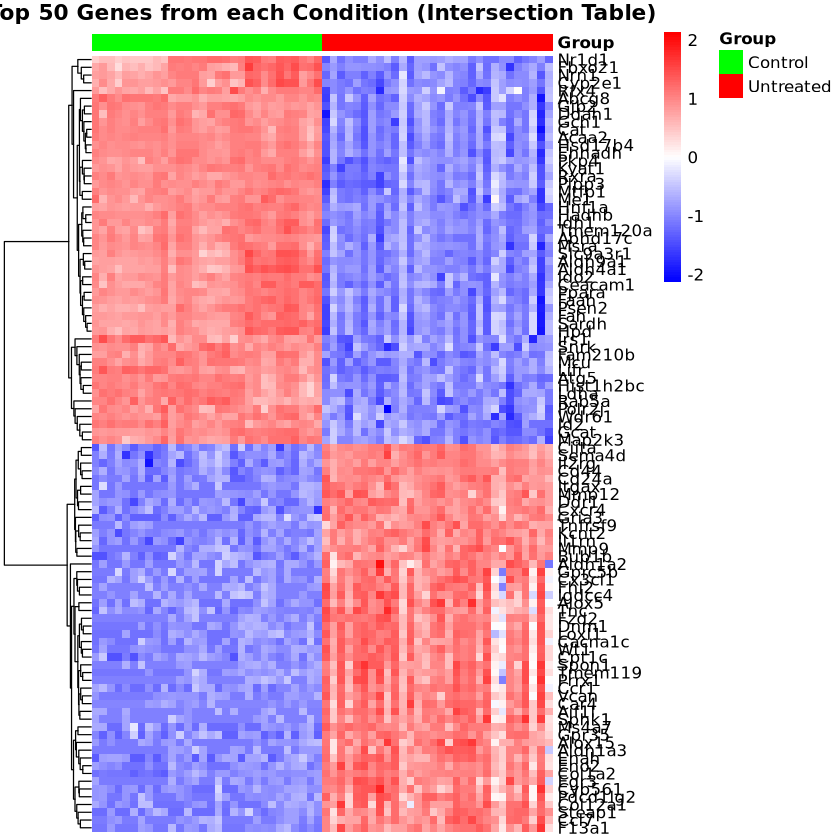

In [19]:
hm<-pheatmap(
  heatmap_data,
  scale = "row",
  cluster_cols = FALSE,
  cluster_rows = TRUE,
  show_colnames = FALSE,
  border_color = NA,              # Removes grid lines
  color = my_palette,             # Blue-White-Red palette
  annotation_col = annotation_col,
  annotation_colors = list(Group = c(Control = "green", Untreated = "red")),
  main = "Top 50 Genes from each Condition (Intersection Table)"
)
pdf("Liver_up_down_paper_HM.pdf", height=12, width=8)
hm
dev.off()

# Intestine

In [20]:
merged_obj<-readRDS("Intestine_ROI_selected_full_slide_for_DE.rds")


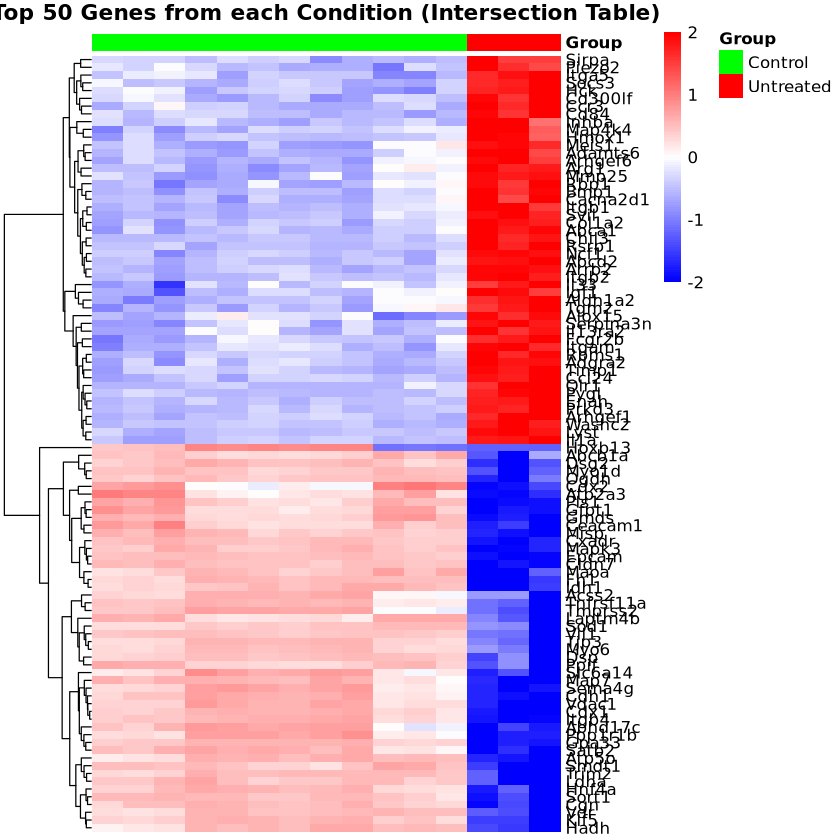

In [22]:
# ==============================
# 1️⃣ Libraries
# ==============================
library(Seurat)
library(edgeR)
library(stringr)
library(pheatmap)
library(RColorBrewer)

# ==============================
# 2️⃣ Subset & Prep
# ==============================
so_obj2 <- subset(merged_obj, subset = condition %in% c("Control", "Untreated"))
so_obj2$donor <- str_extract(so_obj2$ROI_sample, "(?<=_).*")
so_obj2$sample_id <- paste(so_obj2$donor, so_obj2$condition, sep = "_")

# ==============================
# 3️⃣ Pseudo-bulk & Metadata
# ==============================
y <- Seurat2PB(so_obj2, sample = "sample_id", cluster = "ROI_sample")
y <- normLibSizes(y)

sample_df <- data.frame(sample_id = y$samples$sample)
sample_df$donor <- factor(sub("_.*", "", sample_df$sample_id))
sample_df$condition <- factor(sub(".*_", "", sample_df$sample_id), levels = c("Control", "Untreated"))

# ==============================
# 4️⃣ Design & Dispersion (Standard edgeR flow)
# ==============================
design <- model.matrix(~ donor + condition, data = sample_df)
y <- estimateDisp(y, design, robust = TRUE)
fit <- glmQLFit(y, design, robust = TRUE)
# Running the test just to keep the workflow consistent
qlf <- glmQLFTest(fit, coef = "conditionUntreated")

# ==============================
# 5️⃣ Selection from External File
# ==============================
# Load your specific intersection table
de_from_file <- read.table("Intestine_up_down_intersection_table.txt", header = TRUE, row.names = 1, sep = "\t")

# Filter out ribosomal/LINC
#filter_pattern <- "^RPS|^RPL|^LINC"
filter_pattern <- "IGIYAN"

# Separate by condition from the file
up_file <- de_from_file[de_from_file$significance == "Up", ]
down_file <- de_from_file[de_from_file$significance == "Down", ]

# Remove ribosomal/LINC and select top 50 by FDR
top_50_up_genes <- rownames(up_file)[!grepl(filter_pattern, rownames(up_file), ignore.case = TRUE)]
top_50_up <- head(top_50_up_genes[order(up_file[top_50_up_genes, "FDR"])], 50)

top_50_down_genes <- rownames(down_file)[!grepl(filter_pattern, rownames(down_file), ignore.case = TRUE)]
top_50_down <- head(top_50_down_genes[order(down_file[top_50_down_genes, "FDR"])], 50)

# Combine for 100 genes total
top_genes <- c(top_50_up, top_50_down)

# ==============================
# 6️⃣ Heatmap
# ==============================
lcpm <- cpm(y, log = TRUE)

# Ensure genes exist in the matrix
plot_genes <- intersect(top_genes, rownames(lcpm))
heatmap_data <- lcpm[plot_genes, , drop = FALSE]

# Order samples: Control first, then Untreated
ord <- order(sample_df$condition)
heatmap_data <- heatmap_data[, ord]

annotation_col <- data.frame(Group = sample_df$condition)
rownames(annotation_col) <- colnames(lcpm)
annotation_col <- annotation_col[ord, , drop = FALSE]

# Set up Blue-White-Red Palette
my_palette <- colorRampPalette(c("blue", "white", "red"))(100)

pheatmap(
  heatmap_data,
  scale = "row",
  cluster_cols = FALSE,
  cluster_rows = TRUE,
  show_colnames = FALSE,
  border_color = NA,              # Removes grid lines
  color = my_palette,             # Blue-White-Red palette
  annotation_col = annotation_col,
  annotation_colors = list(Group = c(Control = "green", Untreated = "red")),
  main = "Top 50 Genes from each Condition (Intersection Table)",  breaks = seq(-2, 2, length.out = 101)
)

pdf 
  2

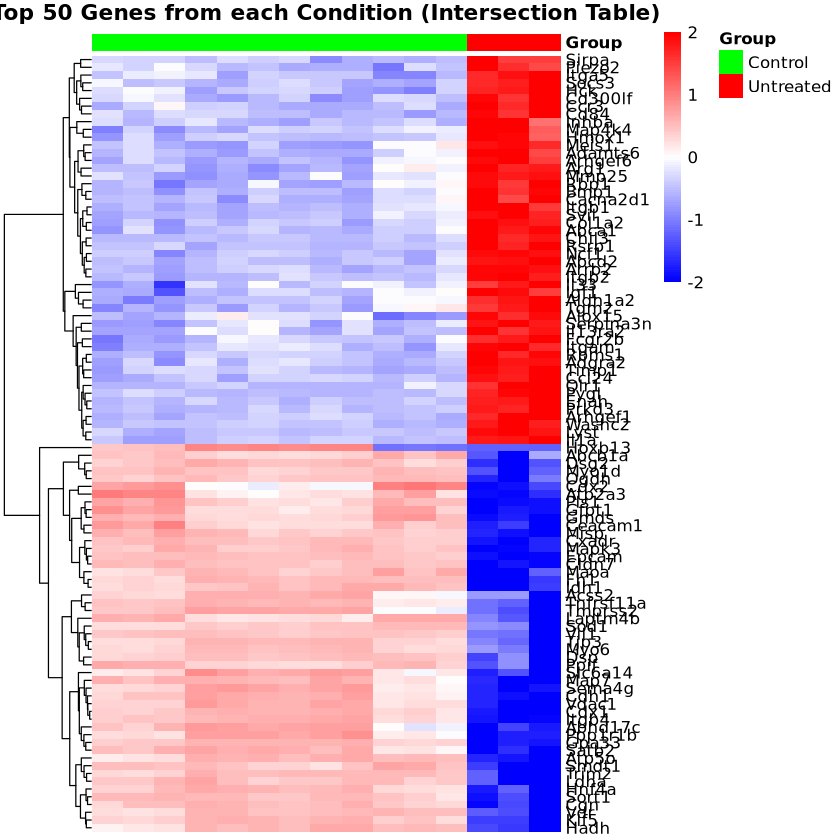

In [24]:
hm<-pheatmap(
  heatmap_data,
  scale = "row",
  cluster_cols = FALSE,
  cluster_rows = TRUE,
  show_colnames = FALSE,
  border_color = NA,              # Removes grid lines
  color = my_palette,             # Blue-White-Red palette
  annotation_col = annotation_col,
  annotation_colors = list(Group = c(Control = "green", Untreated = "red")),
  main = "Top 50 Genes from each Condition (Intersection Table)", breaks = seq(-2, 2, length.out = 101)
)
pdf("Intestine_up_down_paper_HM.pdf", height=12, width=8)
hm
dev.off()